# RAF-DB ResNet-18 + MLP Affinity-Loss Ablation

This notebook runs a controlled 2 x 2 ablation study:

| Experiment | ResNet-18 initialization | Affinity loss |
|---|---|---|
| `random_ce` | Random/default initialization | No |
| `pretrained_ce` | MS-Celeb checkpoint | No |
| `random_ce_affinity` | Random/default initialization | Yes |
| `pretrained_ce_affinity` | MS-Celeb checkpoint | Yes |

The training pipeline follows
`MLP_Affinity_RAF_DB_Training_old.ipynb`, including its exact shared
configuration: 30 epochs, four DataLoader workers, global PyTorch/NumPy
seeding, transforms, model, MLP head, affinity loss, AdamW optimizer,
ReduceLROnPlateau schedule, center initialization, and validation macro-F1
checkpoint selection.

Each experiment resets the legacy seed and behaves like a fresh standalone
execution of the old notebook. Only the two ablated components vary:
ResNet-18 initialization and whether affinity loss is included.

## 1. Imports


In [1]:
import gc
import hashlib
import json
import random
import shutil
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from IPython.display import display
from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import models, transforms
from tqdm import tqdm

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 8)


## 2. Exact legacy configuration and randomness

`CONFIG` below is the original configuration from the old notebook. The
four-experiment runner keeps ablation bookkeeping outside this dictionary so
the training configuration remains unchanged.

The old notebook's `num_workers=4` behavior is intentionally restored.
Before a clean run, restart the kernel and execute from the first cell.

In [2]:
SEED = 24520031

CONFIG = {
    'raf_path': '../../dataset/RAF',
    'label_file': '../../dataset/list_patition_label.txt',
    'image_size': 224,
    'batch_size': 64,
    'epochs': 30,
    'lr': 1e-4,
    'min_lr': 1e-5,
    'weight_decay': 1e-4,
    'num_workers': 4,
    'num_classes': 7,
    'hidden_dim': 256,
    'dropout': 0.3,
    'lambda_aff': 0.05,
    'plateau_factor': 0.5,
    'plateau_patience': 1,
    'plateau_threshold': 5e-3,
    'backbone_checkpoint': 'models/resnet18_msceleb.pth',
    'train_from_scratch': False,
    'max_tsne_samples': 1500,
}

EMOTION_LABELS = {
    0: 'Surprise', 1: 'Fear', 2: 'Disgust', 3: 'Happiness',
    4: 'Sadness', 5: 'Anger', 6: 'Neutral'
}

display(pd.Series(CONFIG, name='value').to_frame())

# Ablation bookkeeping only; these do not alter the legacy training config.
FEATURE_DIM = 512
PROJECT_ROOT = Path.cwd().resolve()
MODEL_CHECKPOINTS = {
    "random_ce": PROJECT_ROOT / "rafdb_resnet18_mlp_random_ce.pth",
    "pretrained_ce": (
        PROJECT_ROOT / "rafdb_resnet18_mlp_pretrained_ce.pth"
    ),
    "random_ce_affinity": (
        PROJECT_ROOT / "rafdb_resnet18_mlp_random_ce_affinity.pth"
    ),
    "pretrained_ce_affinity": (
        PROJECT_ROOT / "rafdb_resnet18_mlp_pretrained_ce_affinity.pth"
    ),
}
FORCE_RETRAIN = CONFIG['train_from_scratch']
TARGET_NAMES = [
    EMOTION_LABELS[index] for index in range(CONFIG['num_classes'])
]


def reset_legacy_rng(seed=SEED):
    # These are the exact explicit seed calls in the old notebook.
    torch.manual_seed(seed)
    np.random.seed(seed)


reset_legacy_rng()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('Device:', device)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
print('Model directory:', PROJECT_ROOT)

,value
raf_path,../../dataset/RAF
label_file,../../dataset/list_patition_label.txt
image_size,224
batch_size,64
epochs,30
lr,0.0001
min_lr,0.00001
weight_decay,0.0001
num_workers,4
num_classes,7


Device: cuda
GPU: NVIDIA GeForce RTX 3080 Ti
Model directory: /home/jupyter-iec2024iot08/yangtze/Other/CS231/methods/ResNet18-Discriminative-loss


## 3. Four-experiment matrix


In [3]:
EXPERIMENTS = [
    {
        "name": "random_ce",
        "display_name": "Random init + CE",
        "pretrained": False,
        "use_affinity": False,
    },
    {
        "name": "pretrained_ce",
        "display_name": "Pretrained + CE",
        "pretrained": True,
        "use_affinity": False,
    },
    {
        "name": "random_ce_affinity",
        "display_name": "Random init + CE + affinity",
        "pretrained": False,
        "use_affinity": True,
    },
    {
        "name": "pretrained_ce_affinity",
        "display_name": "Pretrained + CE + affinity",
        "pretrained": True,
        "use_affinity": True,
    },
]

EXPERIMENT_ORDER = [experiment["name"] for experiment in EXPERIMENTS]
DISPLAY_ORDER = [experiment["display_name"] for experiment in EXPERIMENTS]
EXPERIMENT_COLORS = dict(
    zip(DISPLAY_ORDER, sns.color_palette("colorblind", len(EXPERIMENTS)))
)

experiment_table = pd.DataFrame(EXPERIMENTS)
experiment_table["affinity_weight"] = experiment_table["use_affinity"].map(
    {False: 0.0, True: CONFIG["lambda_aff"]}
)
display(experiment_table)


,name,display_name,pretrained,use_affinity,affinity_weight
0,random_ce,Random init + CE,False,False,0.00
1,pretrained_ce,Pretrained + CE,True,False,0.00
2,random_ce_affinity,Random init + CE + affinity,False,True,0.05
3,pretrained_ce_affinity,Pretrained + CE + affinity,True,True,0.05


## 4. RAF-DB dataset and fixed split

The split code is identical in substance to the old notebook:
`train_test_split(..., test_size=0.2, random_state=SEED, stratify=labels)`.
Therefore every experiment uses the same 9,816 training and 2,455 validation
images. Validation and affinity-center initialization use evaluation
transforms, while training uses the old resize, horizontal-flip, and
rotation augmentation sequence.

In [4]:
class RAFDBDataset(Dataset):

    def __init__(self, image_root, label_file, split="train", transform=None):

        self.image_root = Path(image_root)
        self.transform = transform

        samples = []

        with open(label_file, "r") as f:
            for line in f:

                name, label = line.strip().split()

                if not name.startswith(split):
                    continue

                samples.append(
                    (
                        self.image_root / name,
                        int(label) - 1
                    )
                )

        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        img_path, label = self.samples[idx]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

train_tfms = transforms.Compose(
    [
        transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225],
        ),
    ]
)

eval_tfms = transforms.Compose(
    [
        transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225],
        ),
    ]
)

full_train_dataset = RAFDBDataset(
    CONFIG["raf_path"],
    CONFIG["label_file"],
    "train",
    train_tfms
)

full_eval_dataset = RAFDBDataset(
    CONFIG["raf_path"],
    CONFIG["label_file"],
    "train",
    eval_tfms
)

test_dataset = RAFDBDataset(
    CONFIG["raf_path"],
    CONFIG["label_file"],
    "test",
    eval_tfms
)

all_train_indices = np.arange(len(full_train_dataset))
all_train_labels = np.array(
    [label for _, label in full_train_dataset.samples]
)
train_idx, val_idx = train_test_split(
    all_train_indices,
    test_size=0.2,
    random_state=SEED,
    stratify=all_train_labels,
)

train_dataset = Subset(full_train_dataset, train_idx.tolist())
val_dataset = Subset(full_eval_dataset, val_idx.tolist())
center_dataset = Subset(full_eval_dataset, train_idx.tolist())
# validation_records = full_eval_dataset.df.iloc[val_idx].reset_index(drop=True)


def make_experiment_loaders():
    # Deliberately omit an explicit generator to match the old notebook.
    # Four workers, shuffling, and transforms follow the old notebook.
    return {
        "train": DataLoader(
            train_dataset,
            batch_size=CONFIG["batch_size"],
            shuffle=True,
            num_workers=CONFIG["num_workers"],
            pin_memory=True,
        ),
        "val": DataLoader(
            val_dataset,
            batch_size=CONFIG["batch_size"],
            shuffle=False,
            num_workers=CONFIG["num_workers"],
            pin_memory=True,
        ),
        "center": DataLoader(
            center_dataset,
            batch_size=CONFIG["batch_size"],
            shuffle=False,
            num_workers=CONFIG["num_workers"],
            pin_memory=True,
        ),
        "test": DataLoader(
            test_dataset,
            batch_size=CONFIG["batch_size"],
            shuffle=False,
            num_workers=CONFIG["num_workers"],
            pin_memory=True,
        ),
    }


print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

Train samples: 9816
Validation samples: 2455
Test samples: 3068


## 5. ResNet-18 + MLP model and affinity loss


In [5]:
def resolve_path(path):
    path = Path(path)
    return path if path.is_absolute() else (Path.cwd() / path).resolve()


PRETRAINED_CHECKPOINT = resolve_path(CONFIG["backbone_checkpoint"])


def load_resnet18_checkpoint(backbone, checkpoint_path):
    checkpoint = torch.load(
        checkpoint_path,
        map_location="cpu",
        weights_only=False,
    )
    state_dict = checkpoint.get("state_dict", checkpoint)
    backbone.load_state_dict(state_dict, strict=True)


class ResNet18MLP(nn.Module):
    feature_dim = FEATURE_DIM

    def __init__(
        self,
        num_classes=7,
        hidden_dim=256,
        dropout=0.3,
        pretrained_checkpoint=None,
    ):
        super().__init__()
        backbone = models.resnet18(weights=None)
        if pretrained_checkpoint is not None:
            load_resnet18_checkpoint(backbone, pretrained_checkpoint)

        self.encoder = nn.Sequential(*list(backbone.children())[:-1])
        self.classifier = nn.Sequential(
            nn.Linear(self.feature_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, images):
        features = self.encoder(images).flatten(1)
        logits = self.classifier(features)
        return features, logits


class AffinityLoss(nn.Module):
    def __init__(self, num_classes=7, feat_dim=512, eps=1e-6):
        super().__init__()
        self.centers = nn.Parameter(torch.zeros(num_classes, feat_dim))
        self.eps = eps

    def forward(self, features, labels):
        batch_centers = self.centers[labels]
        intra_class_distance = (
            (features - batch_centers).pow(2).sum(dim=1).mean()
        )
        center_mean = self.centers.mean(dim=0, keepdim=True)
        center_spread = (
            (self.centers - center_mean).pow(2).sum(dim=1).mean()
        )
        return intra_class_distance / (center_spread + self.eps)


def build_model(spec):
    checkpoint_path = PRETRAINED_CHECKPOINT if spec["pretrained"] else None
    return ResNet18MLP(
        num_classes=CONFIG["num_classes"],
        hidden_dim=CONFIG["hidden_dim"],
        dropout=CONFIG["dropout"],
        pretrained_checkpoint=checkpoint_path,
    ).to(device)


def build_affinity_loss(spec):
    if not spec["use_affinity"]:
        return None
    return AffinityLoss(
        num_classes=CONFIG["num_classes"],
        feat_dim=ResNet18MLP.feature_dim,
    ).to(device)


## 6. Training and evaluation utilities


In [6]:
@torch.no_grad()
def initialize_affinity_centers(model, affinity_loss, loader):
    model.eval()
    sums = torch.zeros(
        CONFIG["num_classes"],
        ResNet18MLP.feature_dim,
        device=device,
    )
    counts = torch.zeros(CONFIG["num_classes"], device=device)

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        features, _ = model(images)

        for class_id in range(CONFIG["num_classes"]):
            mask = labels == class_id
            if mask.any():
                sums[class_id] += features[mask].sum(dim=0)
                counts[class_id] += mask.sum()

    affinity_loss.centers.data.copy_(
        sums / counts.clamp(min=1).unsqueeze(1)
    )


def run_epoch(
    model,
    affinity_loss,
    loader,
    ce_criterion,
    optimizer=None,
    affinity_weight=0.0,
    desc=None,
):
    is_training = optimizer is not None
    model.train(is_training)
    totals = {"total_loss": 0.0, "ce_loss": 0.0, "affinity_loss": 0.0}
    total_examples = 0
    all_targets = []
    all_predictions = []

    for images, labels in tqdm(loader, desc=desc, leave=False):
        images = images.to(device)
        labels = labels.to(device)

        with torch.set_grad_enabled(is_training):
            features, logits = model(images)
            loss_ce = ce_criterion(logits, labels)
            if affinity_loss is None:
                loss_affinity = features.new_zeros(())
            else:
                loss_affinity = affinity_loss(features, labels)
            loss = loss_ce + affinity_weight * loss_affinity

            if is_training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        batch_size = images.size(0)
        predictions = logits.argmax(dim=1)
        totals["total_loss"] += loss.item() * batch_size
        totals["ce_loss"] += loss_ce.item() * batch_size
        totals["affinity_loss"] += loss_affinity.item() * batch_size
        total_examples += batch_size
        all_targets.append(labels.detach().cpu().numpy())
        all_predictions.append(predictions.detach().cpu().numpy())

    y_true = np.concatenate(all_targets)
    y_pred = np.concatenate(all_predictions)
    return {
        "total_loss": totals["total_loss"] / total_examples,
        "ce_loss": totals["ce_loss"] / total_examples,
        "affinity_loss": totals["affinity_loss"] / total_examples,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0,
        ),
        "weighted_f1": f1_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0,
        ),
        "y_true": y_true,
        "y_pred": y_pred,
    }


def checkpoint_state_dict(module):
    if module is None:
        return None
    return {
        key: value.detach().cpu()
        for key, value in module.state_dict().items()
    }


SIGNATURE_CONFIG_KEYS = [
    "image_size",
    "batch_size",
    "epochs",
    "lr",
    "min_lr",
    "plateau_factor",
    "plateau_patience",
    "plateau_threshold",
    "weight_decay",
    "num_workers",
    "num_classes",
    "hidden_dim",
    "dropout",
    "lambda_aff",
]


_PRETRAINED_FILE_FINGERPRINT = None


def pretrained_file_fingerprint():
    global _PRETRAINED_FILE_FINGERPRINT
    if _PRETRAINED_FILE_FINGERPRINT is None:
        digest = hashlib.sha256()
        with PRETRAINED_CHECKPOINT.open("rb") as checkpoint_file:
            for chunk in iter(lambda: checkpoint_file.read(1024**2), b""):
                digest.update(chunk)
        _PRETRAINED_FILE_FINGERPRINT = {
            "size": PRETRAINED_CHECKPOINT.stat().st_size,
            "sha256": digest.hexdigest(),
        }
    return dict(_PRETRAINED_FILE_FINGERPRINT)


def experiment_signature(spec):
    pretrained_file = (
        pretrained_file_fingerprint() if spec["pretrained"] else None
    )

    payload = {
        "seed": SEED,
        "experiment": spec,
        "config": {key: CONFIG[key] for key in SIGNATURE_CONFIG_KEYS},
        "train_indices_sha256": hashlib.sha256(
            np.asarray(train_idx, dtype=np.int64).tobytes()
        ).hexdigest(),
        "val_indices_sha256": hashlib.sha256(
            np.asarray(val_idx, dtype=np.int64).tobytes()
        ).hexdigest(),
        "pretrained_file": pretrained_file,
    }
    serialized = json.dumps(payload, sort_keys=True).encode("utf-8")
    return hashlib.sha256(serialized).hexdigest(), payload


def signature_payloads_compatible(saved_payload, current_payload):
    if not isinstance(saved_payload, dict):
        return False

    saved_core = {
        key: value
        for key, value in saved_payload.items()
        if key != "pretrained_file"
    }
    current_core = {
        key: value
        for key, value in current_payload.items()
        if key != "pretrained_file"
    }
    if saved_core != current_core:
        return False

    saved_file = saved_payload.get("pretrained_file")
    current_file = current_payload.get("pretrained_file")
    if saved_file is None or current_file is None:
        return saved_file is None and current_file is None
    if saved_file.get("size") != current_file.get("size"):
        return False

    saved_sha256 = saved_file.get("sha256")
    current_sha256 = current_file.get("sha256")
    return not (saved_sha256 and current_sha256) or (
        saved_sha256 == current_sha256
    )


def checkpoint_matches_experiment(checkpoint, signature, payload):
    return checkpoint.get("signature") == signature or (
        signature_payloads_compatible(
            checkpoint.get("signature_payload"),
            payload,
        )
    )


def archive_checkpoint(checkpoint_path, checkpoint):
    status = (
        "complete"
        if checkpoint.get("training_completed", False)
        else "incomplete"
    )
    best_epoch = int(checkpoint.get("best_epoch", 0))
    signature_prefix = str(checkpoint.get("signature", "unknown"))[:12]
    modified_ns = checkpoint_path.stat().st_mtime_ns
    archive_path = checkpoint_path.with_name(
        f"{checkpoint_path.stem}.{status}.best_epoch_{best_epoch:03d}."
        f"{signature_prefix}.{modified_ns}.pth"
    )
    if not archive_path.exists():
        shutil.copy2(checkpoint_path, archive_path)
    print("Archived existing checkpoint:", archive_path)
    return archive_path


def experiment_paths(spec):
    return {"checkpoint": MODEL_CHECKPOINTS[spec["name"]]}


def build_evaluation_report(metrics):
    report = classification_report(
        metrics["y_true"],
        metrics["y_pred"],
        labels=list(range(CONFIG["num_classes"])),
        target_names=TARGET_NAMES,
        output_dict=True,
        zero_division=0,
    )
    report_df = (
        pd.DataFrame(report)
        .T.rename_axis("label")
        .reset_index()
    )
    return report_df


## 7. Legacy-compatible experiment runner

Each run resets the old notebook's PyTorch and NumPy seeds, creates ordinary
DataLoaders without explicit generators, then constructs the model,
criterion, optimizer, scheduler, and affinity centers in the old order.
This makes every variant comparable to a fresh standalone execution of the
legacy notebook.

In [7]:
def run_experiment(spec):
    print("\n" + "=" * 88)
    print(spec["display_name"])
    print("=" * 88)

    reset_legacy_rng(SEED)
    loaders = make_experiment_loaders()
    paths = experiment_paths(spec)
    signature, signature_payload = experiment_signature(spec)

    model = build_model(spec)
    affinity_loss = build_affinity_loss(spec)
    ce_criterion = nn.CrossEntropyLoss()
    affinity_weight = CONFIG["lambda_aff"] if spec["use_affinity"] else 0.0

    checkpoint_exists = paths["checkpoint"].exists()
    should_train = True
    saved_checkpoint = None
    if checkpoint_exists:
        saved_checkpoint = torch.load(
            paths["checkpoint"],
            map_location="cpu",
            weights_only=False,
        )
        checkpoint_is_compatible = checkpoint_matches_experiment(
            saved_checkpoint, signature, signature_payload
        )
        if FORCE_RETRAIN:
            print("Forced retraining requested.")
        elif not checkpoint_is_compatible:
            print(
                "Different experiment configuration found; "
                "starting a fresh run."
            )
        else:
            should_train = not (
                saved_checkpoint.get("training_completed", False)
                and saved_checkpoint.get("completed_epochs")
                == CONFIG["epochs"]
            )
            if should_train:
                print(
                    "Incomplete checkpoint found; restarting this run."
                )

    if should_train and saved_checkpoint is not None:
        archive_checkpoint(paths["checkpoint"], saved_checkpoint)
    history_df = pd.DataFrame()

    if should_train:
        parameters = list(model.parameters())
        if affinity_loss is not None:
            parameters += list(affinity_loss.parameters())

        # Match the old notebook: optimizer and scheduler are constructed
        # before affinity centers are initialized.
        optimizer = torch.optim.AdamW(
            parameters,
            lr=CONFIG["lr"],
            weight_decay=CONFIG["weight_decay"],
        )
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="max",
            factor=CONFIG["plateau_factor"],
            patience=CONFIG["plateau_patience"],
            threshold=CONFIG["plateau_threshold"],
            min_lr=CONFIG["min_lr"],
        )

        if affinity_loss is not None:
            initialize_affinity_centers(
                model,
                affinity_loss,
                loaders["center"],
            )

        history_rows = []
        best_val_macro_f1 = -1.0

        for epoch in range(1, CONFIG["epochs"] + 1):
            current_lr = optimizer.param_groups[0]["lr"]
            train_metrics = run_epoch(
                model,
                affinity_loss,
                loaders["train"],
                ce_criterion,
                optimizer=optimizer,
                affinity_weight=affinity_weight,
                desc=f"{spec['name']} train {epoch:02d}",
            )
            val_metrics = run_epoch(
                model,
                affinity_loss,
                loaders["val"],
                ce_criterion,
                affinity_weight=affinity_weight,
                desc=f"{spec['name']} val {epoch:02d}",
            )
            scheduler.step(val_metrics["macro_f1"])
            history_row = {
                "epoch": epoch,
                "lr": current_lr,
                **{
                    f"train_{key}": value
                    for key, value in train_metrics.items()
                    if not key.startswith("y_")
                },
                **{
                    f"val_{key}": value
                    for key, value in val_metrics.items()
                    if not key.startswith("y_")
                },
            }
            history_rows.append(history_row)
            history_df = pd.DataFrame(history_rows)

            if val_metrics["macro_f1"] > best_val_macro_f1:
                best_val_macro_f1 = val_metrics["macro_f1"]
                torch.save(
                    {
                        "experiment": spec,
                        "signature": signature,
                        "signature_payload": signature_payload,
                        "seed": SEED,
                        "training_completed": False,
                        "completed_epochs": epoch,
                        "best_epoch": epoch,
                        "history": list(history_rows),
                        "best_val_metrics": {
                            key: value
                            for key, value in val_metrics.items()
                            if not key.startswith("y_")
                        },
                        "model_state_dict": checkpoint_state_dict(model),
                        "affinity_state_dict": checkpoint_state_dict(
                            affinity_loss
                        ),
                    },
                    paths["checkpoint"],
                )

            next_lr = optimizer.param_groups[0]["lr"]
            print(
                f"Epoch {epoch:02d} | "
                f"lr={current_lr:.2e}->{next_lr:.2e} | "
                f"train_acc={train_metrics['accuracy']:.4f} | "
                f"val_acc={val_metrics['accuracy']:.4f} | "
                f"val_macro_f1={val_metrics['macro_f1']:.4f}"
            )

        completed_checkpoint = torch.load(
            paths["checkpoint"],
            map_location="cpu",
            weights_only=False,
        )
        completed_checkpoint["training_completed"] = True
        completed_checkpoint["completed_epochs"] = CONFIG["epochs"]
        completed_checkpoint["history"] = history_rows
        torch.save(completed_checkpoint, paths["checkpoint"])
    else:
        print("Loading compatible saved model:", paths["checkpoint"])
        history_df = pd.DataFrame(saved_checkpoint.get("history", []))

    checkpoint = torch.load(
        paths["checkpoint"],
        map_location=device,
        weights_only=False,
    )
    if not checkpoint_matches_experiment(
        checkpoint, signature, signature_payload
    ):
        raise ValueError(
            f"{paths['checkpoint']} does not match the current experiment."
        )

    model.load_state_dict(checkpoint["model_state_dict"])
    if affinity_loss is not None:
        affinity_loss.load_state_dict(checkpoint["affinity_state_dict"])

    val_metrics = run_epoch(
        model,
        affinity_loss,
        loaders["val"],
        ce_criterion,
        affinity_weight=affinity_weight,
        desc=f"{spec['name']} best validation",
    )
    test_metrics = run_epoch(
        model,
        affinity_loss,
        loaders["test"],
        ce_criterion,
        affinity_weight=affinity_weight,
        desc=f"{spec['name']} test",
    )
    validation_report_df = build_evaluation_report(val_metrics)
    report_df = build_evaluation_report(test_metrics)

    summary = {
        "experiment": spec["name"],
        "display_name": spec["display_name"],
        "pretraining": (
            "MS-Celeb pretrained" if spec["pretrained"] else "Random init"
        ),
        "affinity_loss": "Yes" if spec["use_affinity"] else "No",
        "affinity_weight": affinity_weight,
        "best_epoch": checkpoint["best_epoch"],
        "val_accuracy": val_metrics["accuracy"],
        "val_balanced_accuracy": val_metrics["balanced_accuracy"],
        "val_macro_f1": val_metrics["macro_f1"],
        "test_accuracy": test_metrics["accuracy"],
        "test_balanced_accuracy": test_metrics["balanced_accuracy"],
        "test_macro_f1": test_metrics["macro_f1"],
        "test_weighted_f1": test_metrics["weighted_f1"],
        "test_ce_loss": test_metrics["ce_loss"],
        "test_affinity_loss": test_metrics["affinity_loss"],
        "test_total_loss": test_metrics["total_loss"],
        "checkpoint": str(paths["checkpoint"]),
    }

    print("Best epoch:", summary["best_epoch"])
    print("Validation macro-F1:", f"{summary['val_macro_f1']:.4f}")
    print("Test accuracy:", f"{summary['test_accuracy']:.4f}")
    print("Test macro-F1:", f"{summary['test_macro_f1']:.4f}")

    result = {
        "summary": summary,
        "history": history_df,
        "validation_metrics": val_metrics,
        "test_metrics": test_metrics,
        "validation_report": validation_report_df,
        "report": report_df,
        "paths": paths,
    }

    del model, affinity_loss, ce_criterion, loaders
    if should_train:
        del optimizer, scheduler
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return result


## 8. Setup smoke test

This verifies both initialization paths and output shapes without training.
The experiment runner resets the legacy RNG afterward, so this diagnostic
cell cannot change the training initialization or batch order.

In [8]:
if not PRETRAINED_CHECKPOINT.exists():
    raise FileNotFoundError(
        f"Pretrained checkpoint not found: {PRETRAINED_CHECKPOINT}"
    )

dummy_images = torch.zeros(
    2,
    3,
    CONFIG["image_size"],
    CONFIG["image_size"],
    device=device,
)

for pretrained in (False, True):
    smoke_spec = {
        "pretrained": pretrained,
        "use_affinity": False,
    }
    smoke_model = build_model(smoke_spec)
    with torch.no_grad():
        smoke_features, smoke_logits = smoke_model(dummy_images)
    assert smoke_features.shape == (2, ResNet18MLP.feature_dim)
    assert smoke_logits.shape == (2, CONFIG["num_classes"])
    print(
        "Pretrained" if pretrained else "Random init",
        "model output:",
        tuple(smoke_features.shape),
        tuple(smoke_logits.shape),
    )
    del smoke_model

del dummy_images
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


Random init model output: (2, 512) (2, 7)
Pretrained model output: (2, 512) (2, 7)


## 9. Run or load all four experiments

This is the long-running cell. It trains all variants for 30 epochs using
four DataLoader workers, matching the old notebook.

Each experiment uses its explicitly named checkpoint in the repository
root. With `CONFIG['train_from_scratch']`
set to `False`, compatible completed checkpoints are loaded. Before any
incomplete or incompatible checkpoint is replaced, it is copied to a
uniquely named root-level `.pth` file.

In [9]:
experiment_outputs = {}
summary_rows = []
per_class_rows = []

for experiment in EXPERIMENTS:
    output = run_experiment(experiment)
    experiment_outputs[experiment["name"]] = output
    summary_rows.append(output["summary"])

    class_rows = output["report"].loc[
        output["report"]["label"].isin(TARGET_NAMES)
    ].copy()
    class_rows.insert(0, "experiment", experiment["name"])
    class_rows.insert(1, "display_name", experiment["display_name"])
    per_class_rows.append(class_rows)

summary_df = pd.DataFrame(summary_rows)
per_class_df = pd.concat(per_class_rows, ignore_index=True)

summary_columns = [
    "display_name",
    "pretraining",
    "affinity_loss",
    "best_epoch",
    "val_accuracy",
    "val_macro_f1",
    "test_accuracy",
    "test_balanced_accuracy",
    "test_macro_f1",
    "test_weighted_f1",
]
display(
    summary_df[summary_columns]
    .sort_values("test_macro_f1", ascending=False)
    .style.format(
        {
            "val_accuracy": "{:.4f}",
            "val_macro_f1": "{:.4f}",
            "test_accuracy": "{:.4f}",
            "test_balanced_accuracy": "{:.4f}",
            "test_macro_f1": "{:.4f}",
            "test_weighted_f1": "{:.4f}",
        }
    )
)



Random init + CE
Loading compatible saved model: /home/jupyter-iec2024iot08/yangtze/Other/CS231/methods/ResNet18-Discriminative-loss/rafdb_resnet18_mlp_random_ce.pth


Best epoch: 12
Validation macro-F1: 0.2912
Test accuracy: 0.3748
Test macro-F1: 0.2888

Pretrained + CE
Loading compatible saved model: /home/jupyter-iec2024iot08/yangtze/Other/CS231/methods/ResNet18-Discriminative-loss/rafdb_resnet18_mlp_pretrained_ce.pth


Best epoch: 9
Validation macro-F1: 0.6332
Test accuracy: 0.7181
Test macro-F1: 0.6173

Random init + CE + affinity
Loading compatible saved model: /home/jupyter-iec2024iot08/yangtze/Other/CS231/methods/ResNet18-Discriminative-loss/rafdb_resnet18_mlp_random_ce_affinity.pth


Best epoch: 26
Validation macro-F1: 0.2813
Test accuracy: 0.3771
Test macro-F1: 0.2924

Pretrained + CE + affinity
Loading compatible saved model: /home/jupyter-iec2024iot08/yangtze/Other/CS231/methods/ResNet18-Discriminative-loss/rafdb_resnet18_mlp_pretrained_ce_affinity.pth


Best epoch: 26
Validation macro-F1: 0.5485
Test accuracy: 0.6450
Test macro-F1: 0.5490


,display_name,pretraining,affinity_loss,best_epoch,val_accuracy,val_macro_f1,test_accuracy,test_balanced_accuracy,test_macro_f1,test_weighted_f1
1,Pretrained + CE,MS-Celeb pretrained,No,9,0.7324,0.6332,0.7181,0.6494,0.6173,0.7247
3,Pretrained + CE + affinity,MS-Celeb pretrained,Yes,26,0.6570,0.5485,0.6450,0.5886,0.5490,0.6449
2,Random init + CE + affinity,Random init,Yes,26,0.3654,0.2813,0.3771,0.3483,0.2924,0.3986
0,Random init + CE,Random init,No,12,0.3862,0.2912,0.3748,0.3467,0.2888,0.3760


## 10. Component effects


In [10]:
metric_columns = [
    "test_accuracy",
    "test_balanced_accuracy",
    "test_macro_f1",
    "test_weighted_f1",
]

component_effect_rows = []
for pretraining in ["Random init", "MS-Celeb pretrained"]:
    subset = summary_df.loc[summary_df["pretraining"] == pretraining]
    without_affinity = subset.loc[
        subset["affinity_loss"] == "No"
    ].iloc[0]
    with_affinity = subset.loc[
        subset["affinity_loss"] == "Yes"
    ].iloc[0]
    row = {"comparison": f"Affinity effect | {pretraining}"}
    for metric in metric_columns:
        row[f"delta_{metric}"] = (
            with_affinity[metric] - without_affinity[metric]
        )
    component_effect_rows.append(row)

for affinity_setting in ["No", "Yes"]:
    subset = summary_df.loc[
        summary_df["affinity_loss"] == affinity_setting
    ]
    random_init = subset.loc[
        subset["pretraining"] == "Random init"
    ].iloc[0]
    pretrained = subset.loc[
        subset["pretraining"] == "MS-Celeb pretrained"
    ].iloc[0]
    row = {
        "comparison": (
            f"Pretraining effect | affinity={affinity_setting}"
        )
    }
    for metric in metric_columns:
        row[f"delta_{metric}"] = (
            pretrained[metric] - random_init[metric]
        )
    component_effect_rows.append(row)

component_effects_df = pd.DataFrame(component_effect_rows)
display(
    component_effects_df.style.format(
        {
            column: "{:+.4f}"
            for column in component_effects_df.columns
            if column.startswith("delta_")
        }
    )
)
print("Positive deltas favor the named component.")


,comparison,delta_test_accuracy,delta_test_balanced_accuracy,delta_test_macro_f1,delta_test_weighted_f1
0,Affinity effect | Random init,+0.0023,+0.0015,+0.0036,+0.0226
1,Affinity effect | MS-Celeb pretrained,-0.0730,-0.0608,-0.0683,-0.0797
2,Pretraining effect | affinity=No,+0.3432,+0.3027,+0.3286,+0.3487
3,Pretraining effect | affinity=Yes,+0.2679,+0.2404,+0.2566,+0.2463


Positive deltas favor the named component.


## 11. Pretrained ResNet-18 + affinity learning curves

This cell recreates the old notebook's `Loss` and `Accuracy / F1` figure
from training history stored inside the pretrained + affinity checkpoint.

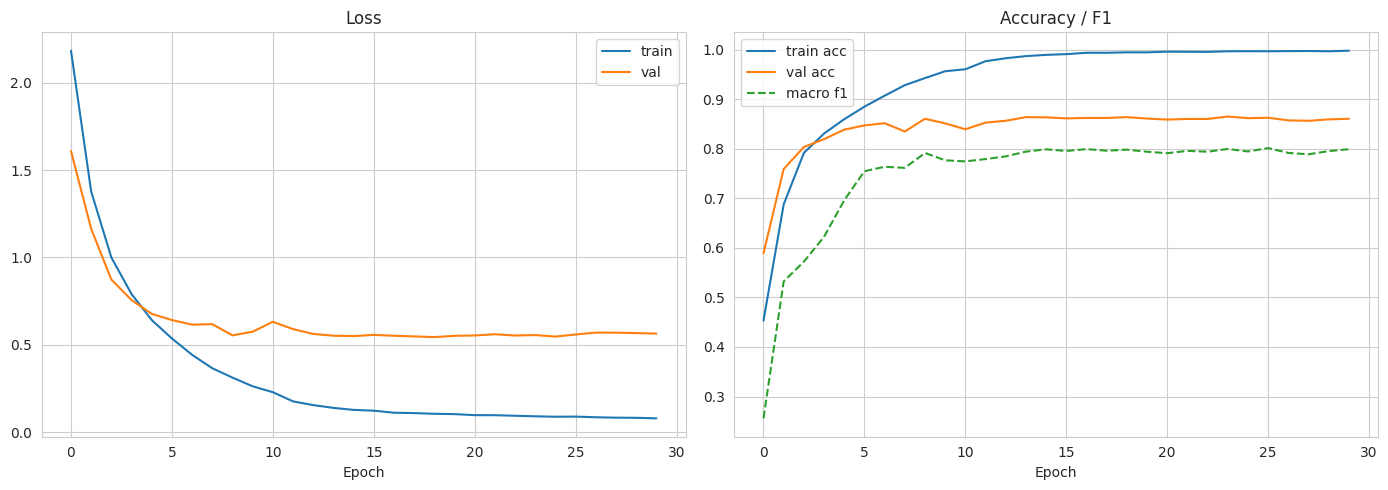

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


history = experiment_outputs["pretrained_ce_affinity"]["history"].copy()
if history.empty:
    raise RuntimeError(
        "Training history is missing from the pretrained + affinity checkpoint."
    )
required_columns = {
    "train_total_loss",
    "val_total_loss",
    "train_accuracy",
    "val_accuracy",
    "val_macro_f1",
}
missing_columns = required_columns.difference(history.columns)
if missing_columns:
    raise ValueError(
        f"History is missing columns: {sorted(missing_columns)}"
    )

# Match MLP_Affinity_RAF_DB_Training_old.ipynb.
sns.set_style("whitegrid")
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(history["train_total_loss"], label="train")
ax[0].plot(history["val_total_loss"], label="val")
ax[0].set_title("Loss")
ax[0].set_xlabel("Epoch")
ax[0].legend()

ax[1].plot(history["train_accuracy"], label="train acc")
ax[1].plot(history["val_accuracy"], label="val acc")
ax[1].plot(
    history["val_macro_f1"],
    label="macro f1",
    linestyle="--",
)
ax[1].set_title("Accuracy / F1")
ax[1].set_xlabel("Epoch")
ax[1].legend()

plt.tight_layout()
plt.show()

## 12. Test performance comparison


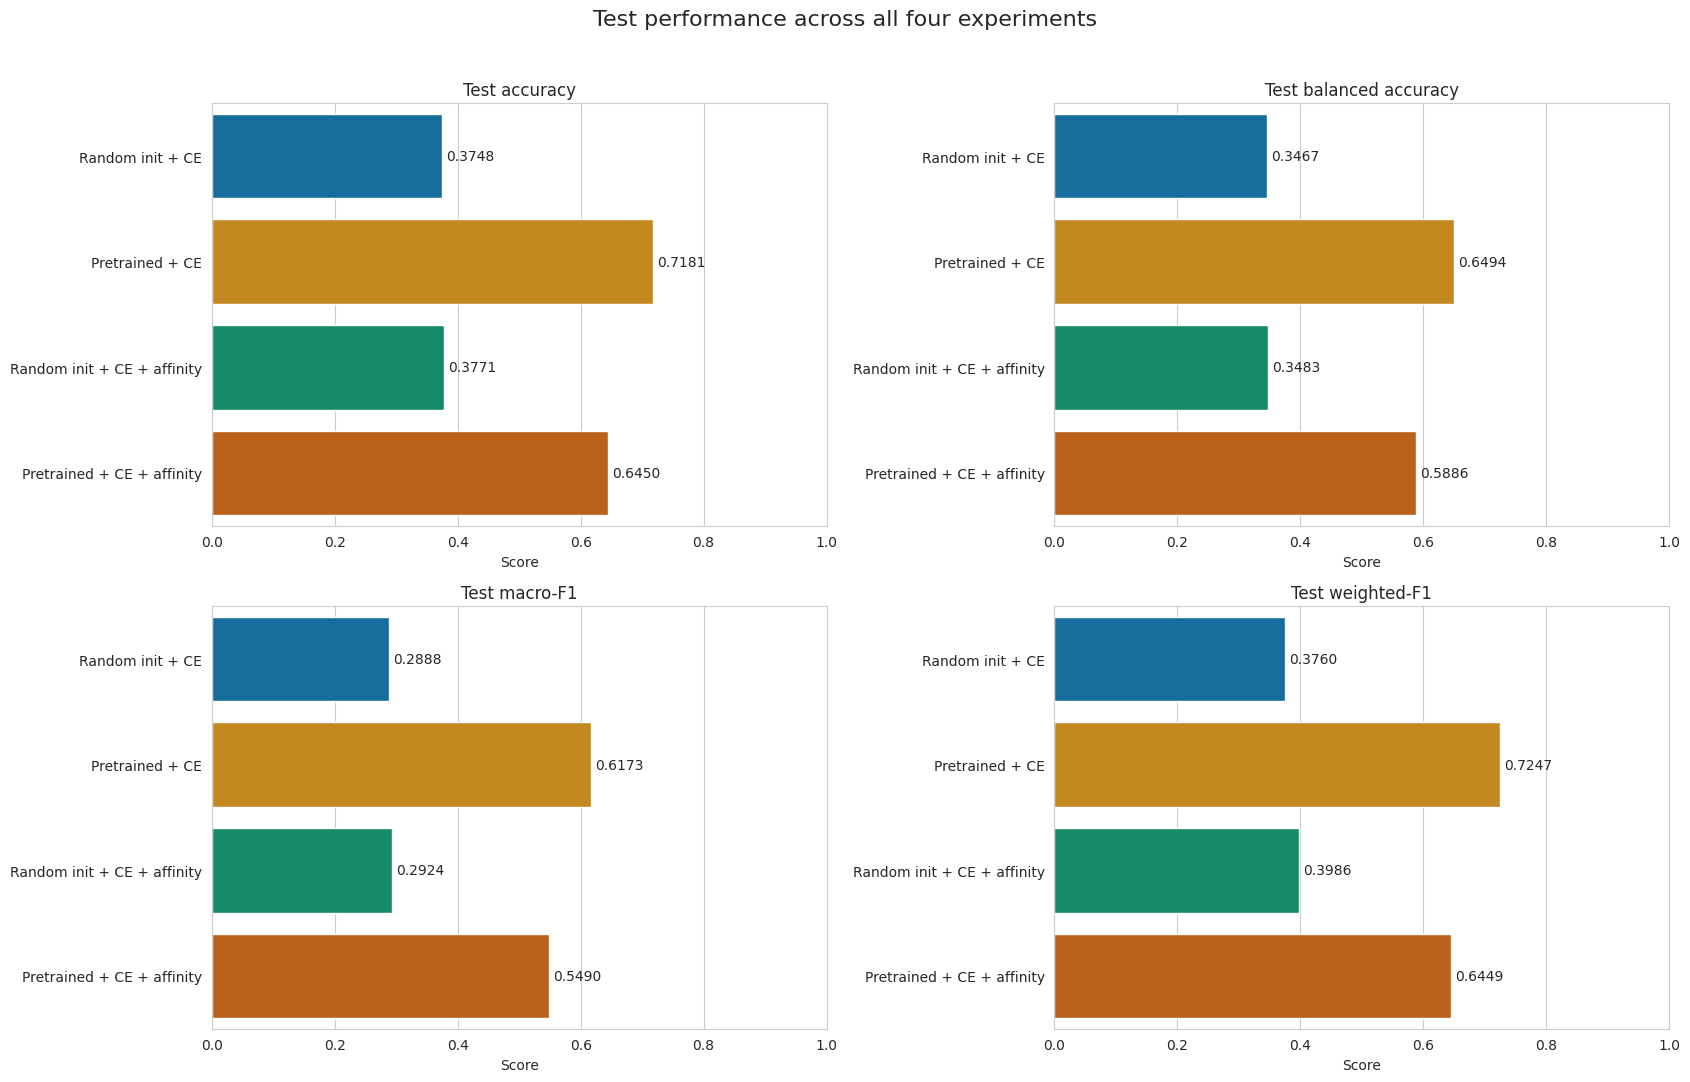

In [12]:
plot_df = summary_df.copy()
plot_df["display_name"] = pd.Categorical(
    plot_df["display_name"], categories=DISPLAY_ORDER, ordered=True
)
plot_df = plot_df.sort_values("display_name")

performance_specs = [
    ("test_accuracy", "Test accuracy"),
    ("test_balanced_accuracy", "Test balanced accuracy"),
    ("test_macro_f1", "Test macro-F1"),
    ("test_weighted_f1", "Test weighted-F1"),
]
fig, axes = plt.subplots(2, 2, figsize=(17, 11))

for axis, (metric, title) in zip(axes.flat, performance_specs):
    sns.barplot(
        data=plot_df,
        y="display_name",
        x=metric,
        order=DISPLAY_ORDER,
        hue="display_name",
        hue_order=DISPLAY_ORDER,
        palette=EXPERIMENT_COLORS,
        legend=False,
        ax=axis,
    )
    axis.set_title(title)
    axis.set_xlim(0, 1)
    axis.set_xlabel("Score")
    axis.set_ylabel("")
    for container in axis.containers:
        axis.bar_label(container, fmt="%.4f", padding=3)

fig.suptitle("Test performance across all four experiments", fontsize=16)
plt.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()


## 13. Pretrained ResNet-18 + affinity confusion matrices

Only the pretrained ResNet-18 + CE + affinity model is shown. This uses the
fixed validation split, matching the original notebook's evaluation figure.

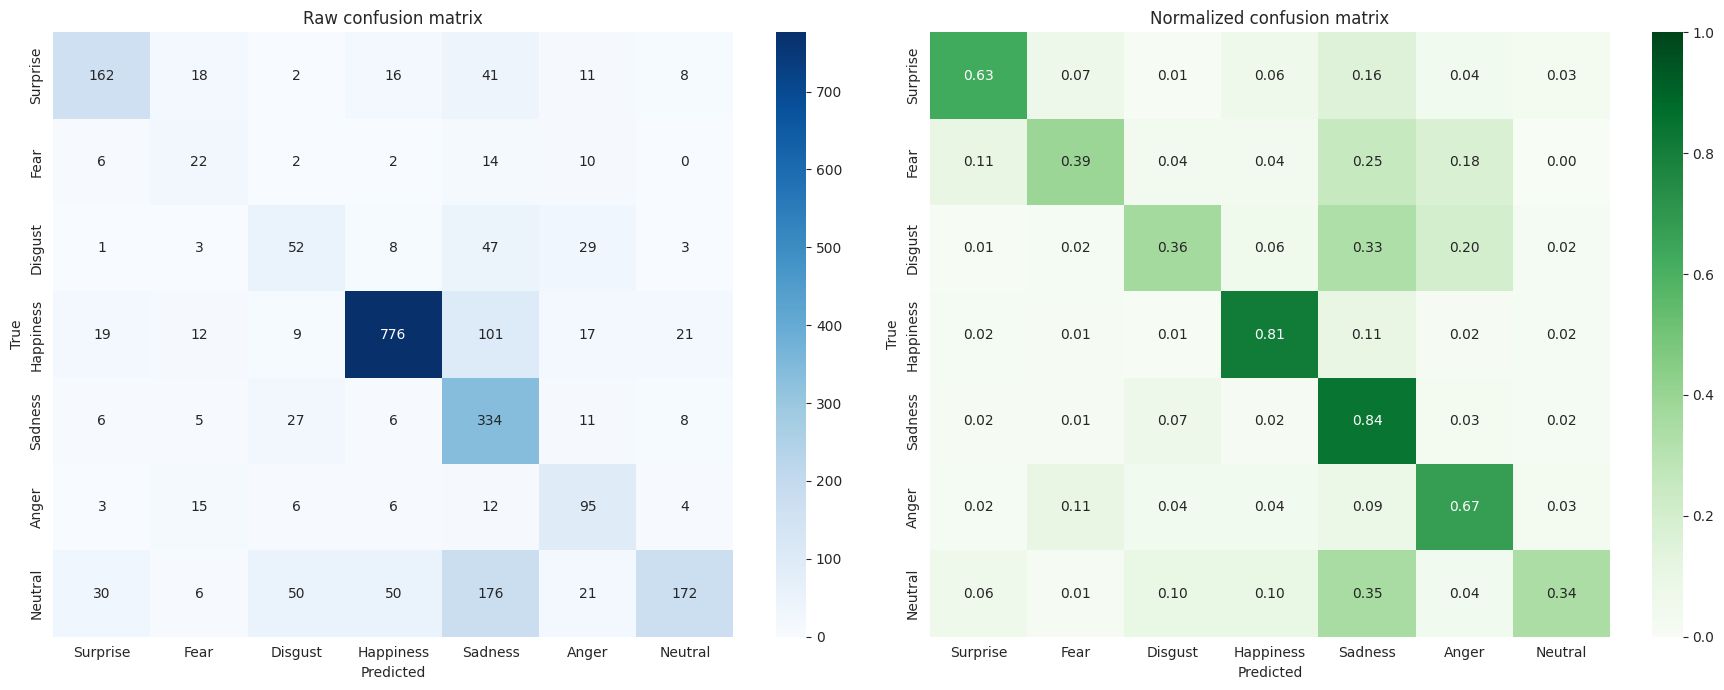

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


target_names = [
    "Surprise",
    "Fear",
    "Disgust",
    "Happiness",
    "Sadness",
    "Anger",
    "Neutral",
]
validation_metrics = experiment_outputs["pretrained_ce_affinity"][
    "validation_metrics"
]
labels = list(range(len(target_names)))
cm = confusion_matrix(
    validation_metrics["y_true"],
    validation_metrics["y_pred"],
    labels=labels,
)
cm_norm = confusion_matrix(
    validation_metrics["y_true"],
    validation_metrics["y_pred"],
    labels=labels,
    normalize="true",
)

# Match MLP_Affinity_RAF_DB_Training_old.ipynb.
sns.set_style("whitegrid")
fig, ax = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names,
    ax=ax[0],
)
ax[0].set_title("Raw confusion matrix")
ax[0].set_xlabel("Predicted")
ax[0].set_ylabel("True")

sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    vmin=0,
    vmax=1,
    xticklabels=target_names,
    yticklabels=target_names,
    ax=ax[1],
)
ax[1].set_title("Normalized confusion matrix")
ax[1].set_xlabel("Predicted")
ax[1].set_ylabel("True")

plt.tight_layout()
plt.show()

## 14. Per-class performance table


,display_name,label,precision,recall,f1-score,support
5,Random init + CE,Anger,0.1903,0.4383,0.2654,162
2,Random init + CE,Disgust,0.1900,0.1187,0.1462,160
1,Random init + CE,Fear,0.1304,0.2838,0.1787,74
3,Random init + CE,Happiness,0.8604,0.4422,0.5842,1185
6,Random init + CE,Neutral,0.4690,0.0779,0.1337,680
4,Random init + CE,Sadness,0.2519,0.7469,0.3768,478
0,Random init + CE,Surprise,0.3559,0.3191,0.3365,329
12,Pretrained + CE,Anger,0.4899,0.7469,0.5917,162
9,Pretrained + CE,Disgust,0.3678,0.4000,0.3832,160
8,Pretrained + CE,Fear,0.3789,0.4865,0.4260,74


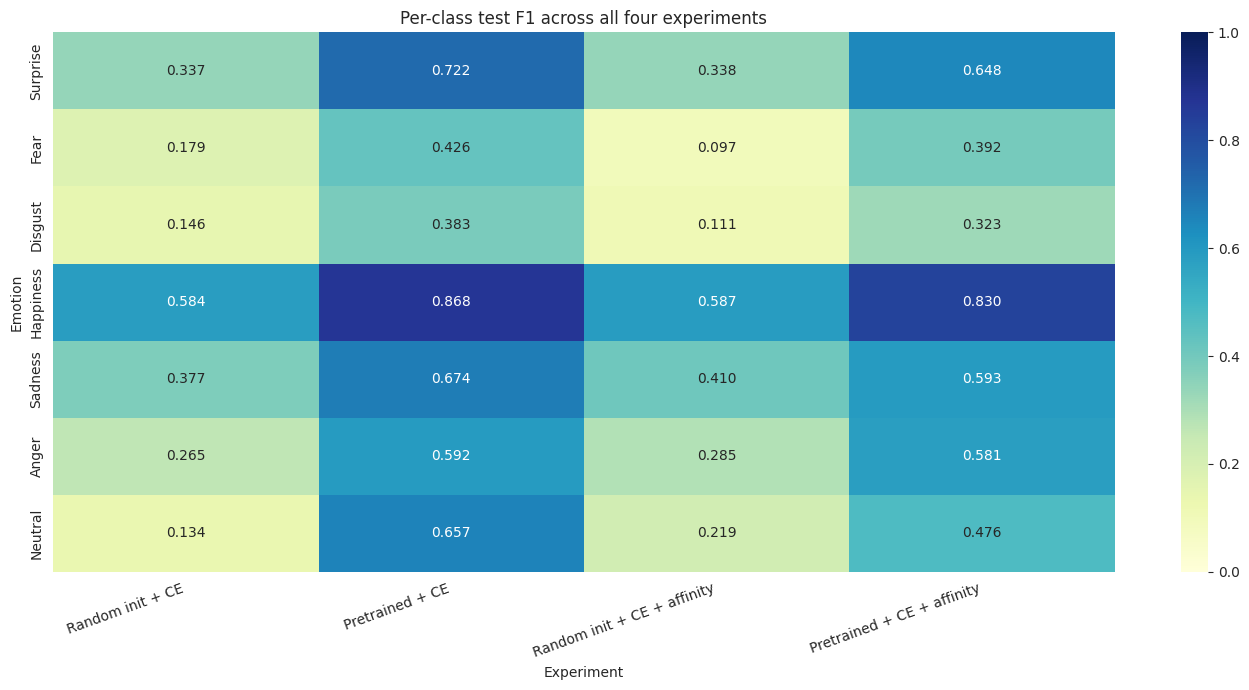

In [14]:
ordered_per_class_df = per_class_df.copy()
ordered_per_class_df["display_name"] = pd.Categorical(
    ordered_per_class_df["display_name"],
    categories=DISPLAY_ORDER,
    ordered=True,
)
ordered_per_class_df = ordered_per_class_df.sort_values(
    ["display_name", "label"]
)

display(
    ordered_per_class_df[
        [
            "display_name",
            "label",
            "precision",
            "recall",
            "f1-score",
            "support",
        ]
    ].style.format(
        {
            "precision": "{:.4f}",
            "recall": "{:.4f}",
            "f1-score": "{:.4f}",
            "support": "{:.0f}",
        }
    )
)

per_class_f1 = ordered_per_class_df.pivot(
    index="label",
    columns="display_name",
    values="f1-score",
).reindex(index=TARGET_NAMES, columns=DISPLAY_ORDER)

plt.figure(figsize=(14, 7))
sns.heatmap(
    per_class_f1,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
)
plt.title("Per-class test F1 across all four experiments")
plt.xlabel("Experiment")
plt.ylabel("Emotion")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


## 15. Pretrained vs. pretrained + affinity t-SNE

This cell is independent of all earlier cells. It reconstructs the
exact stratified validation split (`SEED = 24520031`, 80/20 split),
loads the root-level `pretrained_ce` and `pretrained_ce_affinity`
checkpoints, extracts the same validation examples, and displays the
comparison figure without saving additional artifacts.

The two t-SNE projections are fitted separately with the same samples
and random seed. Compare class compactness and separation, not absolute
axis positions or rotations between panels.

Extract pretrained_ce_affinity features: 100%|██████████| 39/39 [00:02<00:00, 16.99it/s]


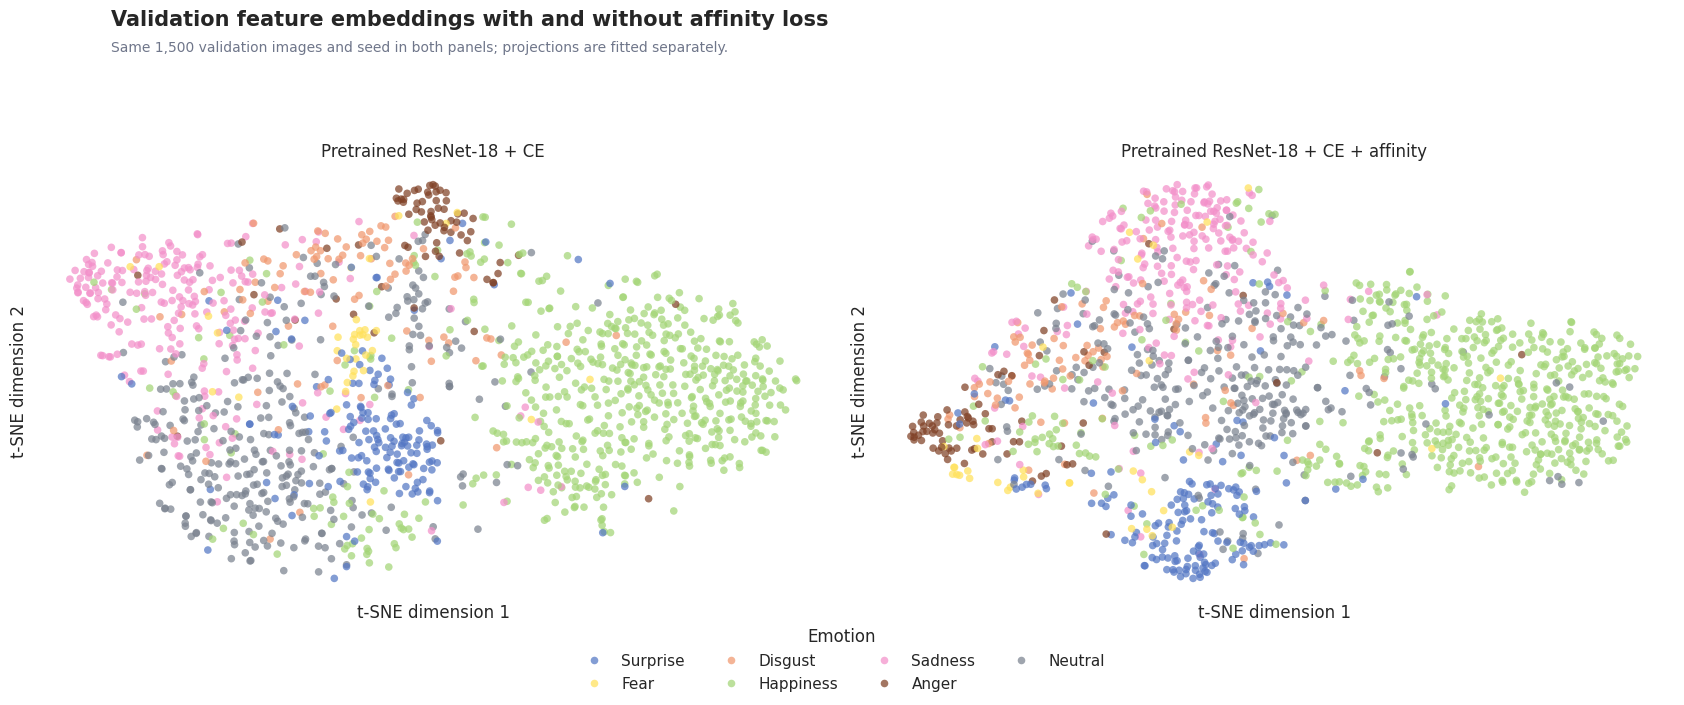

Validation split: 2,455 samples (20% of the RAF-DB training set)
Device: cuda


In [15]:
import gc
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from PIL import Image
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import models, transforms
from tqdm import tqdm


SEED = 24520031
IMAGE_SIZE = 224
BATCH_SIZE = 64
NUM_WORKERS = 4
MAX_TSNE_SAMPLES = 1500
TARGET_NAMES = [
    "Surprise",
    "Fear",
    "Disgust",
    "Happiness",
    "Sadness",
    "Anger",
    "Neutral",
]
PROJECT_ROOT = Path.cwd()
RAF_ROOT = Path(CONFIG["raf_path"])
LABEL_FILE = Path(CONFIG["label_file"])
CHECKPOINTS = {
    "pretrained_ce": PROJECT_ROOT / "rafdb_resnet18_mlp_pretrained_ce.pth",
    "pretrained_ce_affinity": (
        PROJECT_ROOT / "rafdb_resnet18_mlp_pretrained_ce_affinity.pth"
    ),
}

required_paths = [
    LABEL_FILE,
    *CHECKPOINTS.values(),
]
missing_paths = [path for path in required_paths if not path.exists()]
if missing_paths:
    missing_text = "\n".join(
        str(path.resolve()) for path in missing_paths
    )
    raise FileNotFoundError(
        "Run both pretrained experiments first. Missing:\n"
        + missing_text
    )


class TSNERAFDBDataset(Dataset):
    def __init__(self, image_root, label_file, transform):
        self.transform = transform
        self.samples = []

        with open(label_file) as f:
            for line in f:
                name, label = line.strip().split()

                if name.startswith("train"):
                    self.samples.append(
                        (Path(image_root) / name, int(label)-1)
                    )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert("RGB")
        return self.transform(image), label


class TSNEResNet18MLP(nn.Module):
    def __init__(self):
        super().__init__()
        backbone = models.resnet18(weights=None)
        self.encoder = nn.Sequential(
            *list(backbone.children())[:-1]
        )
        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 7),
        )

    def forward(self, images):
        features = self.encoder(images).flatten(1)
        return features, self.classifier(features)


eval_transform = transforms.Compose(
    [
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225],
        ),
    ]
)
full_dataset = TSNERAFDBDataset(
    RAF_ROOT,
    LABEL_FILE,
    eval_transform
)
all_indices = np.arange(len(full_dataset))
all_labels = np.array(
    [label for _, label in full_dataset.samples]
)
_, validation_indices = train_test_split(
    all_indices,
    test_size=0.2,
    random_state=SEED,
    stratify=all_labels,
)
validation_dataset = Subset(
    full_dataset, validation_indices.tolist()
)
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=device.type == "cuda",
)


@torch.inference_mode()
def collect_features(model, loader, description):
    model.eval()
    feature_batches = []
    label_batches = []
    for images, labels in tqdm(loader, desc=description):
        features, _ = model(
            images.to(device, non_blocking=True)
        )
        feature_batches.append(features.cpu().numpy())
        label_batches.append(labels.numpy())
    return (
        np.concatenate(feature_batches),
        np.concatenate(label_batches),
    )


feature_sets = {}
reference_labels = None
for experiment_name, checkpoint_path in CHECKPOINTS.items():
    checkpoint = torch.load(
        checkpoint_path,
        map_location="cpu",
        weights_only=False,
    )
    saved_name = checkpoint.get("experiment", {}).get("name")
    if saved_name != experiment_name:
        raise ValueError(
            f"{checkpoint_path} belongs to {saved_name!r}, "
            f"not {experiment_name!r}."
        )
    model = TSNEResNet18MLP()
    model.load_state_dict(
        checkpoint["model_state_dict"], strict=True
    )
    model = model.to(device)
    features, labels = collect_features(
        model,
        validation_loader,
        f"Extract {experiment_name} features",
    )
    if reference_labels is None:
        reference_labels = labels
    elif not np.array_equal(reference_labels, labels):
        raise RuntimeError(
            "The two feature sets do not use identical samples."
        )
    feature_sets[experiment_name] = features
    del model, checkpoint
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

sample_count = min(MAX_TSNE_SAMPLES, len(reference_labels))
rng = np.random.default_rng(SEED)
if sample_count < len(reference_labels):
    sample_positions = np.sort(
        rng.choice(
            len(reference_labels),
            size=sample_count,
            replace=False,
        )
    )
else:
    sample_positions = np.arange(len(reference_labels))
perplexity = min(
    30,
    max(5, sample_count // 10),
    sample_count - 1,
)

tsne_frames = {}
for experiment_name, features in feature_sets.items():
    scaled_features = StandardScaler().fit_transform(features)
    coordinates = TSNE(
        n_components=2,
        perplexity=perplexity,
        init="pca",
        learning_rate="auto",
        random_state=SEED,
    ).fit_transform(scaled_features[sample_positions])
    frame = pd.DataFrame(
        {
            "tsne_1": coordinates[:, 0],
            "tsne_2": coordinates[:, 1],
            "validation_position": sample_positions,
            "dataset_index": np.asarray(validation_indices)[
                sample_positions
            ],
            "label_id": reference_labels[sample_positions],
        }
    )
    frame["label"] = frame["label_id"].map(
        dict(enumerate(TARGET_NAMES))
    )
    frame["experiment"] = experiment_name
    tsne_frames[experiment_name] = frame

palette = {
    "Surprise": "#5477C4",
    "Fear": "#FFE15B",
    "Disgust": "#F0986E",
    "Happiness": "#A3D576",
    "Sadness": "#F390CA",
    "Anger": "#804126",
    "Neutral": "#7A828F",
}
panel_titles = {
    "pretrained_ce": "Pretrained ResNet-18 + CE",
    "pretrained_ce_affinity": (
        "Pretrained ResNet-18 + CE + affinity"
    ),
}
sns.set_theme(style="white")
fig, axes = plt.subplots(1, 2, figsize=(17, 7))
for axis, experiment_name in zip(
    axes, CHECKPOINTS, strict=True
):
    sns.scatterplot(
        data=tsne_frames[experiment_name],
        x="tsne_1",
        y="tsne_2",
        hue="label",
        hue_order=TARGET_NAMES,
        palette=palette,
        s=30,
        alpha=0.72,
        linewidth=0,
        ax=axis,
    )
    axis.set_title(panel_titles[experiment_name])
    axis.set_xlabel("t-SNE dimension 1")
    axis.set_ylabel("t-SNE dimension 2")
    axis.set_xticks([])
    axis.set_yticks([])
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)
    axis.spines["bottom"].set_visible(False)
    axis.spines["left"].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
for axis in axes:
    legend = axis.get_legend()
    if legend is not None:
        legend.remove()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=4,
    frameon=False,
    title="Emotion",
)
fig.suptitle(
    "Validation feature embeddings with and without affinity loss",
    x=0.07,
    y=0.99,
    ha="left",
    fontsize=15,
    fontweight="semibold",
)
fig.text(
    0.07,
    0.93,
    (
        f"Same {sample_count:,} validation images and seed in both "
        "panels; projections are fitted separately."
    ),
    ha="left",
    color="#6F768A",
    fontsize=10,
)
plt.tight_layout(rect=(0, 0.09, 1, 0.88))

plt.show()
print(
    f"Validation split: {len(validation_indices):,} samples "
    f"(20% of the RAF-DB training set)"
)
print("Device:", device)

## 16. Pretrained ResNet-18 + affinity classification reports

This cell prints and displays both the fixed validation report (comparable
to the old notebook) and the official RAF-DB test report from the in-memory
experiment results.

In [16]:
import pandas as pd
from IPython.display import display
from sklearn.metrics import classification_report

TARGET_NAMES = [
    "Surprise",
    "Fear",
    "Disgust",
    "Happiness",
    "Sadness",
    "Anger",
    "Neutral",
]

selected_output = experiment_outputs["pretrained_ce_affinity"]
splits = {
    "Validation (comparable to the old notebook)": (
        selected_output["validation_metrics"],
        selected_output["validation_report"],
    ),
    "Official RAF-DB test": (
        selected_output["test_metrics"],
        selected_output["report"],
    ),
}

for split_name, (selected_metrics, selected_report) in splits.items():

    print("=" * 72)
    print(f"Pretrained ResNet-18 + CE + affinity | {split_name}")
    print("=" * 72)
    print(
        classification_report(
            selected_metrics["y_true"],
            selected_metrics["y_pred"],
            labels=list(range(len(TARGET_NAMES))),
            target_names=TARGET_NAMES,
            digits=4,
            zero_division=0,
        )
    )
    
    display(
        selected_report.style.format(
            {
                "precision": "{:.4f}",
                "recall": "{:.4f}",
                "f1-score": "{:.4f}",
                "support": "{:.0f}",
            }
        )
    )


Pretrained ResNet-18 + CE + affinity | Validation (comparable to the old notebook)
              precision    recall  f1-score   support

    Surprise     0.7137    0.6279    0.6680       258
        Fear     0.2716    0.3929    0.3212        56
     Disgust     0.3514    0.3636    0.3574       143
   Happiness     0.8981    0.8126    0.8532       955
     Sadness     0.4607    0.8413    0.5954       397
       Anger     0.4897    0.6738    0.5672       141
     Neutral     0.7963    0.3406    0.4771       505

    accuracy                         0.6570      2455
   macro avg     0.5688    0.5789    0.5485      2455
weighted avg     0.7175    0.6570    0.6572      2455



,label,precision,recall,f1-score,support
0,Surprise,0.7137,0.6279,0.6680,258
1,Fear,0.2716,0.3929,0.3212,56
2,Disgust,0.3514,0.3636,0.3574,143
3,Happiness,0.8981,0.8126,0.8532,955
4,Sadness,0.4607,0.8413,0.5954,397
5,Anger,0.4897,0.6738,0.5672,141
6,Neutral,0.7963,0.3406,0.4771,505
7,accuracy,0.6570,0.6570,0.6570,1
8,macro avg,0.5688,0.5789,0.5485,2455
9,weighted avg,0.7175,0.6570,0.6572,2455


Pretrained ResNet-18 + CE + affinity | Official RAF-DB test
              precision    recall  f1-score   support

    Surprise     0.7021    0.6018    0.6481       329
        Fear     0.3077    0.5405    0.3922        74
     Disgust     0.3039    0.3438    0.3226       160
   Happiness     0.8696    0.7932    0.8297      1185
     Sadness     0.4535    0.8577    0.5933       478
       Anger     0.5306    0.6420    0.5810       162
     Neutral     0.7891    0.3412    0.4764       680

    accuracy                         0.6450      3068
   macro avg     0.5652    0.5886    0.5490      3068
weighted avg     0.7080    0.6450    0.6449      3068



,label,precision,recall,f1-score,support
0,Surprise,0.7021,0.6018,0.6481,329
1,Fear,0.3077,0.5405,0.3922,74
2,Disgust,0.3039,0.3438,0.3226,160
3,Happiness,0.8696,0.7932,0.8297,1185
4,Sadness,0.4535,0.8577,0.5933,478
5,Anger,0.5306,0.6420,0.5810,162
6,Neutral,0.7891,0.3412,0.4764,680
7,accuracy,0.6450,0.6450,0.6450,1
8,macro avg,0.5652,0.5886,0.5490,3068
9,weighted avg,0.7080,0.6450,0.6449,3068


## 17. Saved model checkpoints

The notebook saves only these root-level model checkpoints:

- `rafdb_resnet18_mlp_random_ce.pth`
- `rafdb_resnet18_mlp_pretrained_ce.pth`
- `rafdb_resnet18_mlp_random_ce_affinity.pth`
- `rafdb_resnet18_mlp_pretrained_ce_affinity.pth`

Training history is stored inside each checkpoint. Tables and figures are
kept in memory and displayed without creating CSV, NPZ, PNG, or SVG files.
If a checkpoint must be replaced, the previous model is preserved as a
uniquely named root-level `.pth` file.

In [ ]:
# Standalone: show three correct and three incorrect test predictions.
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms

SAMPLE_SEED = 24520031
IMAGE_SIZE = 224
TARGET_NAMES = [
    "Surprise",
    "Fear",
    "Disgust",
    "Happiness",
    "Sadness",
    "Anger",
    "Neutral",
]


def find_project_paths():
    relative_checkpoint = Path(
        "rafdb_resnet18_mlp_pretrained_ce_affinity.pth"
    )
    for root in (Path.cwd(), *Path.cwd().parents):
        raf_root = root / "datasets/raf-db"
        checkpoint_path = root / relative_checkpoint
        if (raf_root / "test_labels.csv").exists() and checkpoint_path.exists():
            return raf_root, checkpoint_path
    raise FileNotFoundError(
        "Could not find RAF-DB and the pretrained + affinity checkpoint "
        "from the current directory or any of its parents."
    )

class StandaloneRAFDBTestDataset(Dataset):

    def __init__(self, image_root, label_file, transform):

        self.transform = transform
        self.samples = []

        with open(label_file) as f:
            for line in f:
                name, label = line.strip().split()

                if name.startswith("test"):
                    self.samples.append(
                        (Path(image_root) / name, int(label)-1)
                    )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        path, label = self.samples[idx]

        image = Image.open(path).convert("RGB")

        return self.transform(image), label, str(path)
    

class StandaloneResNet18MLP(nn.Module):
    def __init__(self):
        super().__init__()
        backbone = models.resnet18(weights=None)
        self.encoder = nn.Sequential(*list(backbone.children())[:-1])
        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 7),
        )

    def forward(self, images):
        features = self.encoder(images).flatten(1)
        return self.classifier(features)


raf_root = Path(CONFIG["raf_path"])
label_file = Path(CONFIG["label_file"])

checkpoint_path = Path(
    "rafdb_resnet18_mlp_pretrained_ce_affinity.pth"
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
eval_transform = transforms.Compose(
    [
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225],
        ),
    ]
)
test_dataset = StandaloneRAFDBTestDataset(
    raf_root,
    label_file,
    eval_transform
)

shuffle_generator = torch.Generator().manual_seed(SAMPLE_SEED)
test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=True,
    generator=shuffle_generator,
    num_workers=0,
    pin_memory=device.type == "cuda",
)

checkpoint = torch.load(
    checkpoint_path,
    map_location="cpu",
    weights_only=False,
)
saved_experiment = checkpoint.get("experiment", {}).get("name")
if saved_experiment != "pretrained_ce_affinity":
    raise ValueError(
        f"Expected pretrained_ce_affinity, found {saved_experiment!r}."
    )
model = StandaloneResNet18MLP()
model.load_state_dict(checkpoint["model_state_dict"], strict=True)
model = model.to(device).eval()

correct_examples = []
incorrect_examples = []
with torch.inference_mode():
    for images, true_ids, image_paths in test_loader:
        logits = model(images.to(device, non_blocking=True))
        confidences, predicted_ids = logits.softmax(dim=1).max(dim=1)
        for path, true_id, predicted_id, confidence in zip(
            image_paths,
            true_ids.tolist(),
            predicted_ids.cpu().tolist(),
            confidences.cpu().tolist(),
        ):
            example = (path, true_id, predicted_id, confidence)
            if true_id == predicted_id and len(correct_examples) < 3:
                correct_examples.append(example)
            elif true_id != predicted_id and len(incorrect_examples) < 3:
                incorrect_examples.append(example)
        if len(correct_examples) == 3 and len(incorrect_examples) == 3:
            break

if len(correct_examples) < 3 or len(incorrect_examples) < 3:
    raise RuntimeError(
        "The test set did not contain at least three examples of each type."
    )

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for row, (examples, result_name, color) in enumerate(
    [
        (correct_examples, "Correct", "#2E8B57"),
        (incorrect_examples, "Incorrect", "#C43B3B"),
    ]
):
    for axis, (path, true_id, predicted_id, confidence) in zip(
        axes[row], examples
    ):
        with Image.open(path) as image:
            axis.imshow(image.convert("RGB"))
        axis.set_title(
            f"{result_name}\n"
            f"True: {TARGET_NAMES[true_id]} | "
            f"Pred: {TARGET_NAMES[predicted_id]}\n"
            f"Confidence: {confidence:.1%}",
            color=color,
            fontsize=10,
        )
        axis.set_xticks([])
        axis.set_yticks([])
        for spine in axis.spines.values():
            spine.set_color(color)
            spine.set_linewidth(3)

fig.suptitle(
    "Pretrained ResNet-18 + CE + affinity: RAF-DB test predictions",
    fontsize=15,
    fontweight="semibold",
)
fig.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()
print("Checkpoint:", checkpoint_path)
print("Best epoch:", checkpoint.get("best_epoch"))
print("Device:", device)


FileNotFoundError: Could not find RAF-DB and the pretrained + affinity checkpoint from the current directory or any of its parents.